# Phase3_FasterRCNN_Training_with_Progress

This notebook trains a **Faster R-CNN** model for the license plate detection project, with live progress bars during training and validation.


## 0. Install packages

Run these only if needed.


In [ ]:
# Uncomment if needed:
# %pip install torch torchvision torchaudio
# %pip install tqdm


## 1. Imports and configuration


In [1]:
import os
import json
import time
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", DEVICE)


Torch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
Device: cpu


## 2. Paths


In [2]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "carplate"
IMAGES_DIR = DATASET_DIR / "images"
ANNOTATIONS_DIR = DATASET_DIR / "annotations"
SPLIT_JSON = PROJECT_ROOT / "data_split.json"
OUTPUT_DIR = PROJECT_ROOT / "fasterrcnn_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("IMAGES_DIR exists:", IMAGES_DIR.exists())
print("ANNOTATIONS_DIR exists:", ANNOTATIONS_DIR.exists())
print("SPLIT_JSON exists:", SPLIT_JSON.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)


PROJECT_ROOT: C:\Users\user\Downloads\Plate-Detection-Project
IMAGES_DIR exists: True
ANNOTATIONS_DIR exists: True
SPLIT_JSON exists: True
OUTPUT_DIR: C:\Users\user\Downloads\Plate-Detection-Project\fasterrcnn_outputs


## 3. Load data split


In [3]:
with open(SPLIT_JSON, "r", encoding="utf-8") as f:
    split_data = json.load(f)

train_files = split_data["train"]
val_files = split_data["val"]
test_files = split_data["test"]

print(f"Train files: {len(train_files)}")
print(f"Val files:   {len(val_files)}")
print(f"Test files:  {len(test_files)}")


Train files: 303
Val files:   65
Test files:  65


## 4. Pascal VOC XML parser


In [4]:
def parse_voc_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    objects = []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        bndbox = obj.find("bndbox")

        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        objects.append({
            "name": name,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects
    }

sample_xml = ANNOTATIONS_DIR / train_files[0].replace(".png", ".xml")
sample_ann = parse_voc_annotation(sample_xml)
sample_ann


{'filename': 'Cars1.png',
 'width': 400,
 'height': 248,
 'objects': [{'name': 'licence', 'bbox': [134.0, 128.0, 262.0, 160.0]}]}

## 5. Dataset class

For Faster R-CNN in torchvision:
- label `0` is background
- our object class `licence` becomes label `1`


In [5]:
CLASS_MAP = {"licence": 1}

class LicensePlateDataset(Dataset):
    def __init__(self, file_list, images_dir, annotations_dir):
        self.file_list = file_list
        self.images_dir = Path(images_dir)
        self.annotations_dir = Path(annotations_dir)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        img_path = self.images_dir / fname
        xml_path = self.annotations_dir / fname.replace(".png", ".xml")

        image = Image.open(img_path).convert("RGB")
        ann = parse_voc_annotation(xml_path)

        boxes = []
        labels = []

        for obj in ann["objects"]:
            xmin, ymin, xmax, ymax = obj["bbox"]
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_MAP[obj["name"]])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd,
        }

        image = F.to_tensor(image)
        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = LicensePlateDataset(train_files, IMAGES_DIR, ANNOTATIONS_DIR)
val_dataset = LicensePlateDataset(val_files, IMAGES_DIR, ANNOTATIONS_DIR)
test_dataset = LicensePlateDataset(test_files, IMAGES_DIR, ANNOTATIONS_DIR)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))


Train dataset size: 303
Val dataset size: 65
Test dataset size: 65


## 6. Quick visualization sanity check


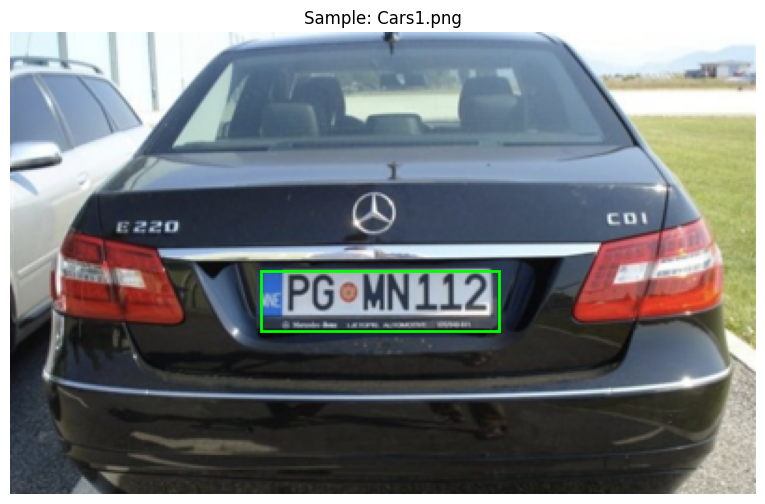

In [6]:
def show_sample(dataset, index=0):
    image, target = dataset[index]
    img_np = image.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.imshow(img_np)

    for box in target["boxes"]:
        xmin, ymin, xmax, ymax = box.tolist()
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor="lime",
            facecolor="none"
        )
        ax.add_patch(rect)

    ax.set_title(f"Sample: {dataset.file_list[index]}")
    ax.axis("off")
    plt.show()

show_sample(train_dataset, index=0)


## 7. DataLoaders


In [7]:
BATCH_SIZE = 2
NUM_WORKERS = 0  # safest on Windows/Jupyter

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 152
Val batches: 33
Test batches: 65


## 8. Build Faster R-CNN


In [8]:
num_classes = 2

weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(DEVICE)
print("Model loaded and moved to:", DEVICE)


Model loaded and moved to: cpu


## 9. Optimizer and settings


In [9]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

NUM_EPOCHS = 8
best_val_score = -1.0

history = {
    "train_loss": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": []
}


## 10. Helper functions with progress bars


In [10]:
def box_iou_single(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, xa2 - xa1) * max(0.0, ya2 - ya1)
    area_b = max(0.0, xb2 - xb1) * max(0.0, yb2 - yb1)

    union = area_a + area_b - inter_area
    return inter_area / union if union > 0 else 0.0

def evaluate_detector(model, data_loader, device, score_thresh=0.5, iou_thresh=0.5):
    model.eval()

    tp, fp, fn = 0, 0, 0
    progress_bar = tqdm(data_loader, desc="Validation", leave=True)

    with torch.no_grad():
        for images, targets in progress_bar:
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output["boxes"].detach().cpu().numpy()
                pred_scores = output["scores"].detach().cpu().numpy()

                keep = pred_scores >= score_thresh
                pred_boxes = pred_boxes[keep]

                gt_boxes = target["boxes"].detach().cpu().numpy()
                matched_gt = set()

                for pb in pred_boxes:
                    best_iou = 0.0
                    best_gt_idx = -1

                    for gt_idx, gb in enumerate(gt_boxes):
                        if gt_idx in matched_gt:
                            continue
                        iou = box_iou_single(pb, gb)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = gt_idx

                    if best_iou >= iou_thresh and best_gt_idx != -1:
                        tp += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        fp += 1

                fn += len(gt_boxes) - len(matched_gt)

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

            progress_bar.set_postfix({
                "precision": f"{precision:.3f}",
                "recall": f"{recall:.3f}",
                "f1": f"{f1:.3f}"
            })

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

def train_one_epoch(model, optimizer, data_loader, device):
    model.train()
    running_loss = 0.0
    progress_bar = tqdm(data_loader, desc="Training", leave=True)

    for batch_idx, (images, targets) in enumerate(progress_bar):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_value = losses.item()
        running_loss += loss_value

        progress_bar.set_postfix({
            "batch_loss": f"{loss_value:.4f}",
            "avg_loss": f"{running_loss / (batch_idx + 1):.4f}"
        })

    return running_loss / max(1, len(data_loader))


## 11. Train the model


In [11]:
best_model_path = OUTPUT_DIR / "best_fasterrcnn_license_plate.pth"

for epoch in range(NUM_EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{NUM_EPOCHS} =====")
    start_time = time.time()

    train_loss = train_one_epoch(model, optimizer, train_loader, DEVICE)
    val_metrics = evaluate_detector(model, val_loader, DEVICE, score_thresh=0.5, iou_thresh=0.5)

    lr_scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])

    epoch_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train loss   : {train_loss:.4f}")
    print(f"  Val precision: {val_metrics['precision']:.4f}")
    print(f"  Val recall   : {val_metrics['recall']:.4f}")
    print(f"  Val F1       : {val_metrics['f1']:.4f}")
    print(f"  Time         : {epoch_time:.1f}s")

    if val_metrics["f1"] > best_val_score:
        best_val_score = val_metrics["f1"]
        torch.save(model.state_dict(), best_model_path)
        print(f"  Saved best model to: {best_model_path}")

    print("-" * 50)

print("Training complete.")
print("Best validation F1:", best_val_score)



===== Epoch 1/8 =====


Training:   0%|          | 0/152 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch [1/8]
  Train loss   : 0.1304
  Val precision: 0.8592
  Val recall   : 0.8841
  Val F1       : 0.8714
  Time         : 2618.7s
  Saved best model to: C:\Users\user\Downloads\Plate-Detection-Project\fasterrcnn_outputs\best_fasterrcnn_license_plate.pth
--------------------------------------------------

===== Epoch 2/8 =====


Training:   0%|          | 0/152 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch [7/8]
  Train loss   : 0.0468
  Val precision: 0.8400
  Val recall   : 0.9130
  Val F1       : 0.8750
  Time         : 2614.9s
--------------------------------------------------

===== Epoch 8/8 =====


Training:   0%|          | 0/152 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch [8/8]
  Train loss   : 0.0461
  Val precision: 0.8630
  Val recall   : 0.9130
  Val F1       : 0.8873
  Time         : 2630.2s
--------------------------------------------------
Training complete.
Best validation F1: 0.888888888888889


## 12. Plot training history


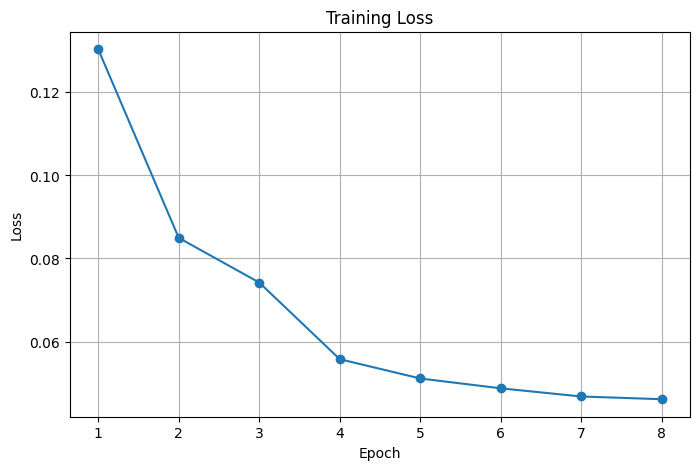

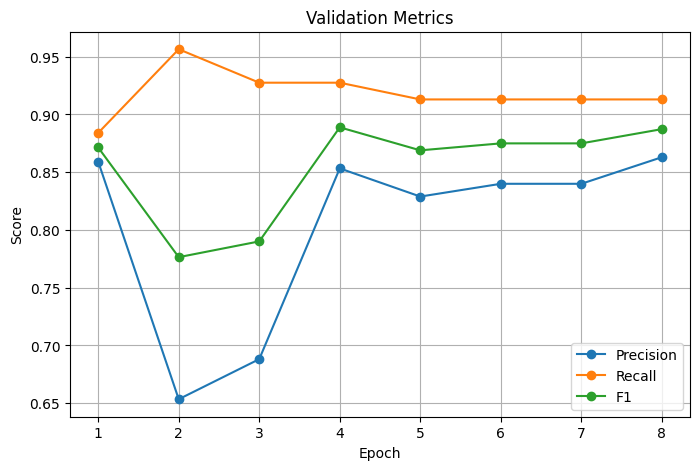

In [12]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["val_precision"], marker="o", label="Precision")
plt.plot(epochs, history["val_recall"], marker="o", label="Recall")
plt.plot(epochs, history["val_f1"], marker="o", label="F1")
plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()


## 13. Evaluate on test set


In [13]:
best_model = fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None)
in_features = best_model.roi_heads.box_predictor.cls_score.in_features
best_model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.to(DEVICE)

test_metrics = evaluate_detector(best_model, test_loader, DEVICE, score_thresh=0.5, iou_thresh=0.5)
print("Test metrics:")
print(test_metrics)


Validation:   0%|          | 0/65 [00:00<?, ?it/s]

Test metrics:
{'tp': 63, 'fp': 7, 'fn': 8, 'precision': 0.9, 'recall': 0.8873239436619719, 'f1': 0.8936170212765958}


## 14. Visualize predictions


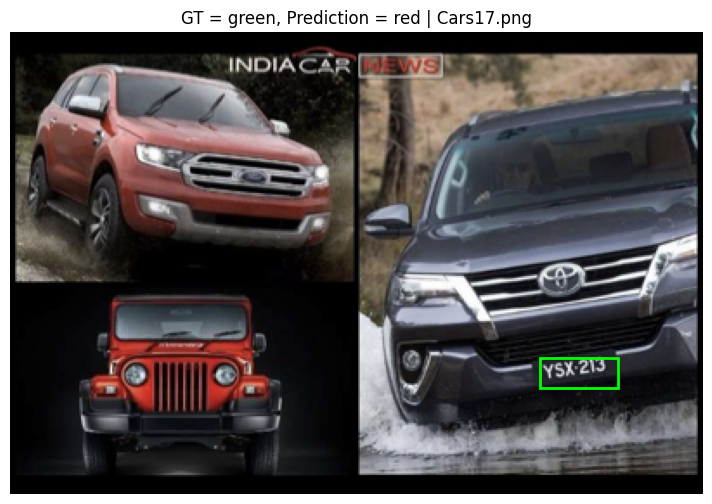

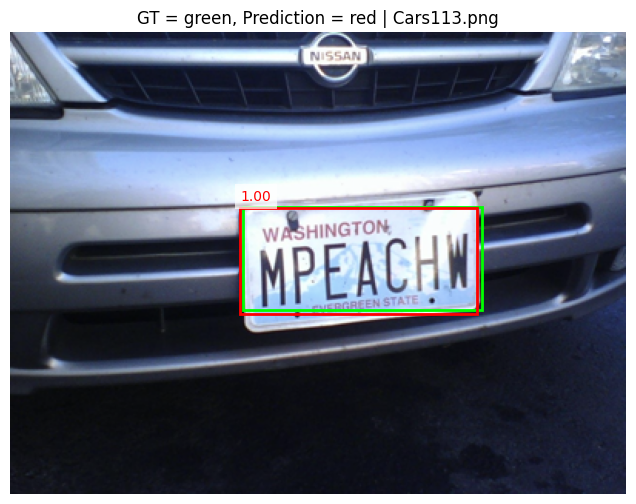

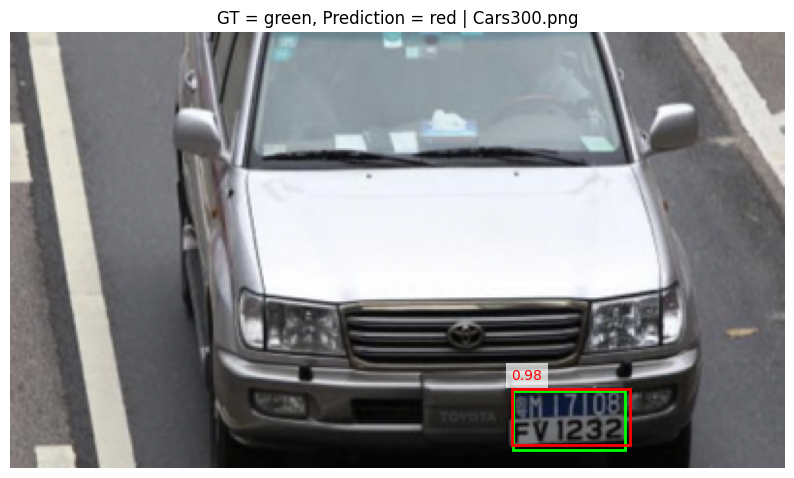

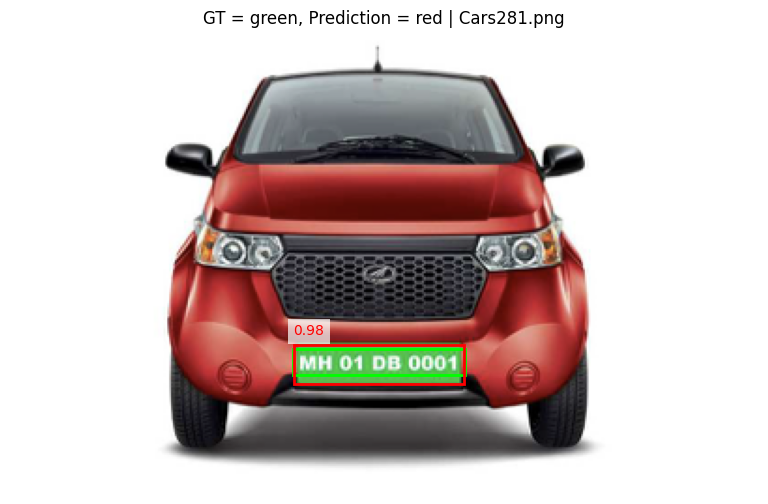

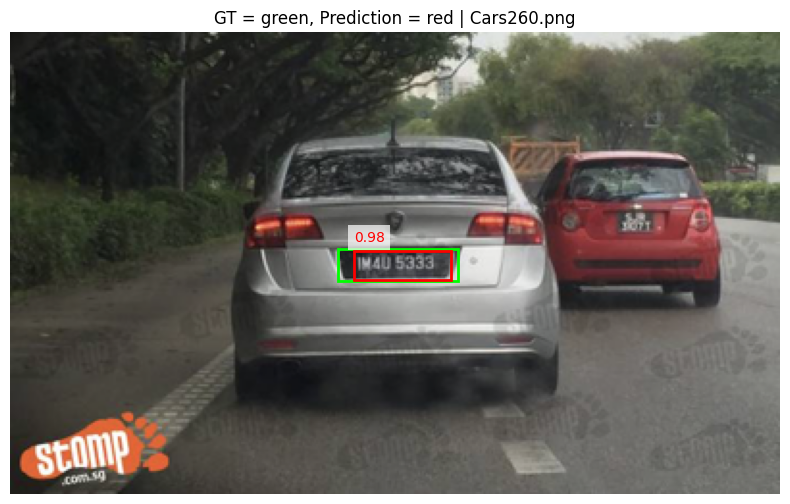

In [14]:
def visualize_predictions(model, dataset, device, num_images=5, score_thresh=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))

    with torch.no_grad():
        for idx in indices:
            image, target = dataset[idx]
            pred = model([image.to(device)])[0]

            img_np = image.permute(1, 2, 0).numpy()

            fig, ax = plt.subplots(1, 1, figsize=(10, 6))
            ax.imshow(img_np)

            for box in target["boxes"]:
                xmin, ymin, xmax, ymax = box.tolist()
                rect = patches.Rectangle(
                    (xmin, ymin),
                    xmax - xmin,
                    ymax - ymin,
                    linewidth=2,
                    edgecolor="lime",
                    facecolor="none"
                )
                ax.add_patch(rect)

            for box, score in zip(pred["boxes"].cpu(), pred["scores"].cpu()):
                if score.item() < score_thresh:
                    continue

                xmin, ymin, xmax, ymax = box.tolist()
                rect = patches.Rectangle(
                    (xmin, ymin),
                    xmax - xmin,
                    ymax - ymin,
                    linewidth=2,
                    edgecolor="red",
                    facecolor="none"
                )
                ax.add_patch(rect)

                ax.text(
                    xmin,
                    max(0, ymin - 5),
                    f"{score.item():.2f}",
                    color="red",
                    fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
                )

            ax.set_title(f"GT = green, Prediction = red | {dataset.file_list[idx]}")
            ax.axis("off")
            plt.show()

visualize_predictions(best_model, test_dataset, DEVICE, num_images=5, score_thresh=0.5)


## 15. Save metrics


In [15]:
results = {
    "best_val_f1": best_val_score,
    "history": history,
    "test_metrics": test_metrics,
    "num_epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "seed": SEED
}

results_path = OUTPUT_DIR / "fasterrcnn_results.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("Saved results to:", results_path)


Saved results to: C:\Users\user\Downloads\Plate-Detection-Project\fasterrcnn_outputs\fasterrcnn_results.json
